# Étape 4 — Évaluation et Comparaison finale des modèles

Ce notebook permet d'entraîner le modèle Random Forest, de comparer ses performances avec la Régression Logistique sur les données de test, de tracer les courbes ROC et de Lift pour l'aide à la décision marketing, et enfin d'extraire le Top 10 des leads à cibler en priorité.

In [ ]:
import sys
import os
import joblib

# Ajout du chemin racine du projet pour résoudre les imports de lead_scoring
sys.path.append(os.path.abspath(os.path.join("..", "..")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import des fonctions de modélisation et d'évaluation
from lead_scoring.src.model import entrainer_random_forest
from lead_scoring.src.evaluate import (
    calculer_metriques, 
    tracer_courbes_roc, 
    tracer_courbes_lift, 
    extraire_top_leads
)

## 1. Chargement des données de test et du modèle de Régression Logistique

Nous rechargeons les jeux de données d'entraînement et de test pré-traités ainsi que notre modèle de Régression Logistique entraîné en Étape 3.

In [2]:
dossier_data = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "processed"))

X_train = pd.read_csv(os.path.join(dossier_data, "X_train.csv"))
X_test = pd.read_csv(os.path.join(dossier_data, "X_test.csv"))
y_train = pd.read_csv(os.path.join(dossier_data, "y_train.csv")).squeeze()
y_test = pd.read_csv(os.path.join(dossier_data, "y_test.csv")).squeeze()

# Chargement du modèle de Régression Logistique
chemin_lr = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "models", "regression_logistique.joblib"))
modele_lr = joblib.load(chemin_lr)

print(f"Données chargées : X_test = {X_test.shape}, y_test = {y_test.shape}")
print("Modèle de Régression Logistique chargé avec succès.")

Données chargées : X_test = (2233, 43), y_test = (2233,)
Modèle de Régression Logistique chargé avec succès.


## 2. Entraînement du modèle Random Forest

Nous entraînons le modèle de Forêt Aléatoire sur les données d'entraînement.

In [3]:
modele_rf = entrainer_random_forest(X_train, y_train, random_state=42, n_estimators=100)

Entraînement du Random Forest en cours...


Random Forest entraîné avec succès.


## 3. Comparaison des métriques de classification

Nous calculons les scores de probabilités et les prédictions binaires sur le jeu de test pour comparer les deux modèles.

In [4]:
# Calcul des probabilités de conversion (scores continus de 0 à 1)
prob_lr = modele_lr.predict_proba(X_test)[:, 1]
prob_rf = modele_rf.predict_proba(X_test)[:, 1]

# Classes prédites (seuil par défaut à 0.5)
pred_lr = (prob_lr >= 0.5).astype(int)
pred_rf = (prob_rf >= 0.5).astype(int)

# Calcul des dictionnaires de métriques
metriques_lr = calculer_metriques(y_test, pred_lr, prob_lr)
metriques_rf = calculer_metriques(y_test, pred_rf, prob_rf)

# Création d'un tableau comparatif
df_comparaison = pd.DataFrame({
    "Régression Logistique": metriques_lr,
    "Random Forest": metriques_rf
}).T

print("Tableau comparatif des performances (Test Set) :")
df_comparaison.round(4)

Tableau comparatif des performances (Test Set) :


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Régression Logistique,0.8253,0.8275,0.7977,0.8123,0.9072
Random Forest,0.8594,0.8229,0.8960,0.8579,0.9206


## 4. Comparaison des courbes ROC

Nous traçons les courbes ROC pour visualiser le pouvoir discriminant de chaque modèle.

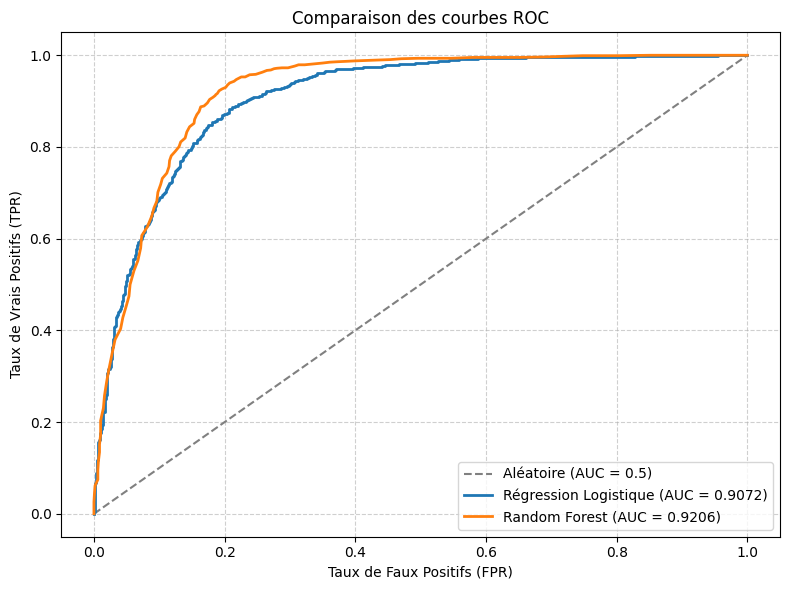

In [5]:
modeles_probs = {
    "Régression Logistique": prob_lr,
    "Random Forest": prob_rf
}
tracer_courbes_roc(y_test, modeles_probs)

**Analyse des courbes ROC :**

- **Pouvoir de discrimination élevé** : Les deux courbes s'élèvent très rapidement vers le coin supérieur gauche, ce qui montre que nos deux modèles sont très performants. La courbe orange du Random Forest (AUC = 0.9206) se situe globalement au-dessus de celle de la Régression Logistique (AUC = 0.9072), confirmant sa supériorité pour classer les prospects.

- **Traduction commerciale** : Si la banque tolère un taux de faux positifs de 20% (ce qui signifie appeler à tort 20% de personnes non intéressées de notre base), le modèle Random Forest permet déjà de capturer **95% de tous les acheteurs réels** (Taux de Vrais Positifs = 95%). Sur une base de 1 000 prospects avec 100 acheteurs réels et 900 non-acheteurs, cela revient à passer 275 appels au total pour signer 95 contrats (95% des ventes possibles) et essuyer 180 refus. Cela évite d'appeler les 725 clients restants de la base.

## 5. Comparaison des courbes de Lift (Gain cumulé)

La courbe de gain cumulé est un outil d'aide à la décision marketing. Elle montre quel pourcentage des acheteurs réels nous captons si nous ciblons un certain pourcentage des prospects ayant les meilleurs scores.

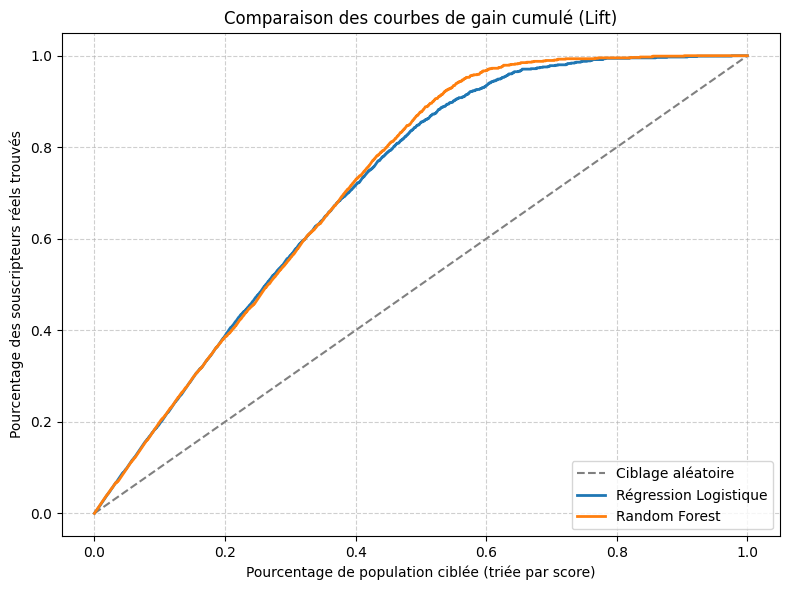

In [6]:
tracer_courbes_lift(y_test, modeles_probs)

### Analyse du graphique des courbes de gain cumulé (Lift)

- **Forte accélération du gain** : Les courbes des deux modèles s'élèvent très rapidement au-dessus de la diagonale grise (ciblage aléatoire). Cela prouve l'efficacité du lead scoring pour prioriser les appels commerciaux.

- **Optimisation des coûts marketing (exemple concret)** :
  - En ciblant le **top 30%** des prospects les plus chauds (courbe orange, Random Forest), on capte près de **56%** de toutes les souscriptions réelles de notre base de test.
  - En élargissant au **top 40%**, on parvient à capturer près de **73%** des acheteurs réels.
  - **Traduction commerciale** : Pour obtenir ces mêmes ventes de manière aléatoire, il aurait fallu appeler respectivement 56% et 73% de la base. Grâce au modèle Random Forest, la banque peut **diviser par deux l'effort et le coût de démarchage** (en appelant 30% au lieu de 56%, ou 40% au lieu de 73%) tout en générant le même niveau de contrats.

## 6. Extraction du Top 10 des leads les plus chauds

Nous extrayons les 10 meilleurs prospects identifiés par le modèle le plus performant (le Random Forest) et affichons leurs caractéristiques réelles (non normalisées) pour qu'ils soient exploitables commercialement.

In [7]:
top_10_leads = extraire_top_leads(X_test, prob_rf, top_n=10)

print("Top 10 des prospects les plus chauds à contacter en priorité :")
top_10_leads[["age", "job", "marital", "education", "balance", "duration", "score_conversion"]]

Top 10 des prospects les plus chauds à contacter en priorité :


,age,job,marital,education,balance,duration,score_conversion
549,32,blue-collar,married,secondary,476,956,1.00
1884,38,housemaid,single,primary,199,1203,1.00
518,39,management,married,tertiary,1423,733,1.00
874,33,management,single,tertiary,2637,583,1.00
1548,50,unknown,married,primary,341,670,1.00
291,35,blue-collar,married,tertiary,2999,1141,1.00
1321,35,self-employed,married,tertiary,3698,106,0.99
2207,49,technician,married,tertiary,523,712,0.99
692,42,technician,married,tertiary,14282,649,0.99
259,37,services,divorced,secondary,319,467,0.99


## 7. Sauvegarde du modèle Random Forest

Nous enregistrons le modèle Random Forest pour pouvoir l'utiliser dans de futures campagnes.

In [8]:
chemin_rf = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "models", "random_forest.joblib"))
joblib.dump(modele_rf, chemin_rf)
print(f"Modèle Random Forest sauvegardé avec succès à l'adresse : {chemin_rf}")

Modèle Random Forest sauvegardé avec succès à l'adresse : C:\Users\Yohan\UQAC\python_UQAC\projet_optimisateur_marketing\models\random_forest.joblib
